In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime as dt

In [2]:
df = pd.read_csv("../data/Walmart.csv")

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Any store must have only one record in a day.

In [7]:
duplicates = df.duplicated(subset=["Store", "Date"]).sum()
duplicates

np.int64(0)

### We should Use datetime to be comfortable with date because date datatype is string.

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format='%d-%m-%Y')
df["Date"].head(10)

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
5   2010-03-12
6   2010-03-19
7   2010-03-26
8   2010-04-02
9   2010-04-09
Name: Date, dtype: datetime64[us]

In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day Of Week"] = df["Date"].dt.day_of_week #Monday = 0 - Saturday = 6

In [10]:
df["Is Holiday"] = df["Holiday_Flag"].astype(bool)

In [11]:
df[["Year","Month","Week","Day Of Week","Is Holiday"]].head(10)

,Year,Month,Week,Day Of Week,Is Holiday
0,2010,2,5,4,False
1,2010,2,6,4,True
2,2010,2,7,4,False
3,2010,2,8,4,False
4,2010,3,9,4,False
5,2010,3,10,4,False
6,2010,3,11,4,False
7,2010,3,12,4,False
8,2010,4,13,4,False
9,2010,4,14,4,False


In [12]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day Of Week
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182,4.0
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0,4.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.0,4.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.0,4.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.0,4.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0,4.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201,0.0


### Which Store had most sale per week

In [13]:
df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(1)

Store
20    3.013978e+08
Name: Weekly_Sales, dtype: float64

### Is "20" Store always had most Weekly sale or not?

In [14]:
sale_by_store = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

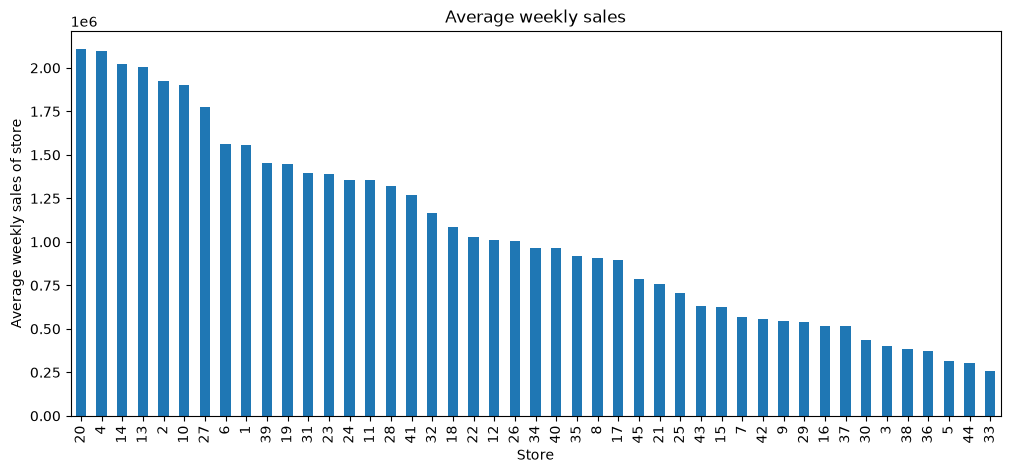

In [15]:
sale_by_store.plot(figsize=(12,5), kind="bar")

plt.xlabel("Store")
plt.ylabel("Average weekly sales of store")
plt.title("Average weekly sales")
plt.show()

### Weekly Sales per year

In [16]:
df.groupby("Year")["Weekly_Sales"].sum()

Year
2010    2.288886e+09
2011    2.448200e+09
2012    2.000133e+09
Name: Weekly_Sales, dtype: float64

### Average Weekly Sales per year

In [17]:
df.groupby("Year")["Weekly_Sales"].mean()

Year
2010    1.059670e+06
2011    1.046239e+06
2012    1.033660e+06
Name: Weekly_Sales, dtype: float64

### Average Weekly Sales per month

In [18]:
df.groupby("Month")["Weekly_Sales"].mean().sort_values(ascending=False)

Month
12    1.281864e+06
11    1.147266e+06
6     1.064325e+06
2     1.053200e+06
8     1.048017e+06
7     1.031748e+06
5     1.031714e+06
4     1.026762e+06
3     1.013309e+06
10    9.996321e+05
9     9.893353e+05
1     9.238846e+05
Name: Weekly_Sales, dtype: float64

### Do holidays affect sales?

In [19]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean().sort_values(ascending=False)

Holiday_Flag
1    1.122888e+06
0    1.041256e+06
Name: Weekly_Sales, dtype: float64

In [20]:
df["Holiday_Flag"].value_counts()

Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

In [21]:
df["Holiday_Flag"].value_counts(normalize=True)*100

Holiday_Flag
0    93.006993
1     6.993007
Name: proportion, dtype: float64

In [22]:
df.groupby("Month")["Holiday_Flag"].sum()

Month
1       0
2     135
3       0
4       0
5       0
6       0
7       0
8       0
9     135
10      0
11     90
12     90
Name: Holiday_Flag, dtype: int64

In [23]:
df.groupby(["Month", "Holiday_Flag"])["Weekly_Sales"].mean()

Month  Holiday_Flag
1      0               9.238846e+05
2      0               1.044557e+06
       1               1.079128e+06
3      0               1.013309e+06
4      0               1.026762e+06
5      0               1.031714e+06
6      0               1.064325e+06
7      0               1.031748e+06
8      0               1.048017e+06
9      0               9.734078e+05
       1               1.042427e+06
10     0               9.996321e+05
11     0               1.039263e+06
       1               1.471273e+06
12     0               1.362121e+06
       1               9.608331e+05
Name: Weekly_Sales, dtype: float64

In [24]:
df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False).head(5)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64

In [25]:
df.groupby("Store")["Weekly_Sales"].mean().sort_values().head(5)

Store
33    259861.692028
44    302748.866014
5     318011.810490
36    373511.992797
38    385731.653287
Name: Weekly_Sales, dtype: float64

In [26]:
df.corr(numeric_only=True)["Weekly_Sales"].sort_values(ascending=False)

Weekly_Sales    1.000000
Month           0.076143
Week            0.074211
Is Holiday      0.036891
Holiday_Flag    0.036891
Fuel_Price      0.009464
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Day Of Week          NaN
Name: Weekly_Sales, dtype: float64

In [27]:
df[df["Store"].isin([20, 33])][["Store", "Date", "Weekly_Sales"]]

,Store,Date,Weekly_Sales
2717,20,2010-02-05,2401395.47
2718,20,2010-02-12,2109107.90
2719,20,2010-02-19,2161549.76
2720,20,2010-02-26,1898193.95
2721,20,2010-03-05,2119213.72
...,...,...,...
4714,33,2012-09-28,242813.51
4715,33,2012-10-05,265444.90
4716,33,2012-10-12,291781.15
4717,33,2012-10-19,254412.34


In [28]:
store_20 = df[df["Store"] == 20]
store_33 = df[df["Store"] == 33]

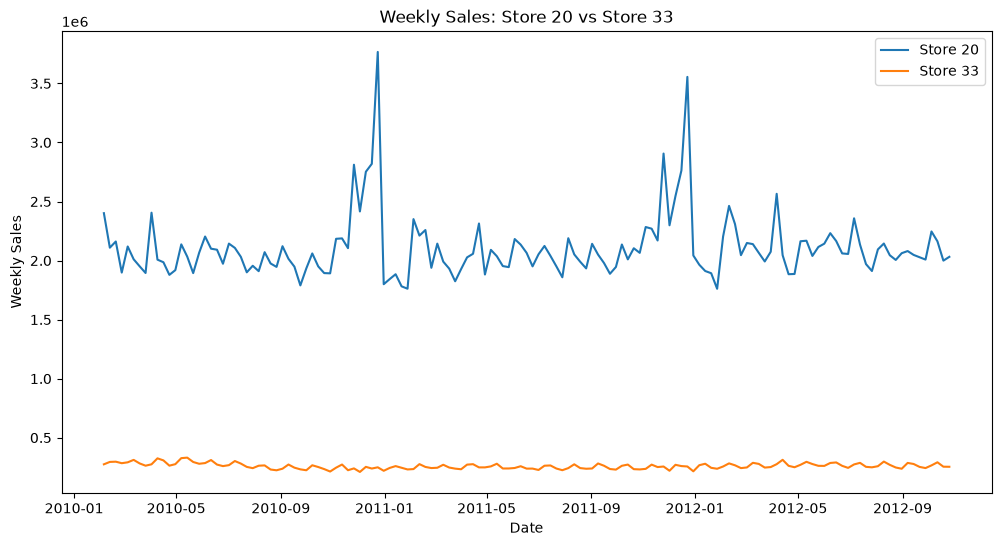

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    store_20["Date"],
    store_20["Weekly_Sales"],
    label="Store 20"
)

plt.plot(
    store_33["Date"],
    store_33["Weekly_Sales"],
    label="Store 33"
)

plt.title("Weekly Sales: Store 20 vs Store 33")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()
plt.show()

###حالا یک سؤال بهتر 🤔

ما الان می‌دانیم فروشگاه ۲۰ فروش بیشتری دارد.

ولی یک سؤال جالب‌تر داریم:

فروشگاه ۲۰ در چه ماه‌هایی جهش فروش دارد؟

این سؤال ما را به سمت تحلیل فصلی (Seasonality) می‌برد.

In [30]:
store_20 = df.loc[df["Store"] == 20]

store_20.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day Of Week,Is Holiday
2717,20,2010-02-05,2401395.47,0,25.92,2.784,204.247194,8.187,2010,2,5,4,False
2718,20,2010-02-12,2109107.90,1,22.12,2.773,204.385747,8.187,2010,2,6,4,True
2719,20,2010-02-19,2161549.76,0,25.43,2.745,204.432100,8.187,2010,2,7,4,False
2720,20,2010-02-26,1898193.95,0,32.32,2.754,204.463087,8.187,2010,2,8,4,False
2721,20,2010-03-05,2119213.72,0,31.75,2.777,204.494073,8.187,2010,3,9,4,False


In [31]:
store_20.sort_values("Weekly_Sales", ascending=False).head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day Of Week,Is Holiday
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484,2010,12,51,4,False
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082,2011,12,51,4,False
2811,20,2011-11-25,2906233.25,1,46.38,3.492,211.412076,7.082,2011,11,47,4,True
2762,20,2010-12-17,2819193.17,0,24.07,3.140,204.632119,7.484,2010,12,50,4,False
2759,20,2010-11-26,2811634.04,1,46.66,3.039,204.962100,7.484,2010,11,47,4,True
2814,20,2011-12-16,2762816.65,0,37.16,3.413,212.068504,7.082,2011,12,50,4,False
2761,20,2010-12-10,2752122.08,0,24.27,3.109,204.687738,7.484,2010,12,49,4,False
2830,20,2012-04-06,2565259.92,0,50.06,3.996,214.238705,7.139,2012,4,14,4,False
2813,20,2011-12-09,2546123.78,0,41.64,3.415,211.866786,7.082,2011,12,49,4,False
2822,20,2012-02-10,2462978.28,1,33.47,3.640,213.118614,6.961,2012,2,6,4,True


### حالا می‌خواهم یک سؤال جدید مطرح کنیم

ما تا الان روی فروشگاه ۲۰ تمرکز کردیم.

اما شاید این الگو فقط مخصوص فروشگاه ۲۰ نباشد.

مثلاً ممکن است در کل Walmart:

ماه دسامبر معمولاً ماه پرفروشی باشد.

و این را قبلاً با میانگین ماهانه دیده‌ایم.

پس حالا می‌خواهم یک قدم مهم‌تر برداریم:

📊 فروش کل هر ماه در طول سال‌ها

این بار به جای mean() می‌خواهیم ببینیم مجموع فروش هر ماه چقدر بوده

In [32]:
df.groupby("Month")["Weekly_Sales"].sum().sort_values(ascending=False)

Month
7     6.500010e+08
4     6.468598e+08
6     6.226299e+08
8     6.130902e+08
3     5.927859e+08
10    5.847848e+08
9     5.787612e+08
12    5.768386e+08
2     5.687279e+08
5     5.571256e+08
11    4.130157e+08
1     3.325984e+08
Name: Weekly_Sales, dtype: float64

### mean() : به‌طور متوسط، یک هفته در این ماه چقدر فروش داشته؟

### sum() : کل فروش ثبت‌شده در تمام رکوردهای این ماه چقدر بوده؟
#### و اینجا تعداد رکوردها اهمیت زیادی پیدا می‌کند.

In [33]:
df.groupby("Month")["Weekly_Sales"].count()

Month
1     360
2     540
3     585
4     630
5     540
6     585
7     630
8     585
9     585
10    585
11    360
12    450
Name: Weekly_Sales, dtype: int64

In [34]:
df[df["Month"]==12].groupby("Year")["Weekly_Sales"].mean()

Year
2010    1.283380e+06
2011    1.280347e+06
Name: Weekly_Sales, dtype: float64

### پس نمی‌توانیم بگوییم:

«دسامبر در هر سه سال پرفروش بوده.»

بلکه نتیجه درست این است:

در سال‌های ۲۰۱۰ و ۲۰۱۱، میانگین فروش هفتگی در ماه دسامبر تقریباً یکسان و بالا بوده است.

In [35]:
df.groupby(["Year","Month"])["Weekly_Sales"].mean().unstack()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2010,NaN,1.057405e+06,1.010666e+06,1.028499e+06,1.037283e+06,1.068034e+06,1.033689e+06,1.042445e+06,9.848216e+05,9.651637e+05,1.126963e+06,1.283380e+06
2011,909466.482389,1.035174e+06,9.964247e+05,1.006784e+06,1.009156e+06,1.054297e+06,1.021828e+06,1.047774e+06,9.815455e+05,1.018118e+06,1.167569e+06,1.280347e+06
2012,938302.620333,1.067020e+06,1.028932e+06,1.049561e+06,1.048703e+06,1.069379e+06,1.041719e+06,1.052670e+06,1.003586e+06,1.024232e+06,NaN,NaN


##### اگر به 3 ماه اخر سال 2010 نگاه کنیم یعنی اکتبر نوامبر و دسامبر میبینیم که فروش یک الگو صعودی داشته است که قابل توجه است و در سال 2011 هم همین الگوی صعودی ادامه داشته است. حال اگر فقط به دسامبر سال 2010 و 2011 نگاه کنیم نیز الگوی جالبی مشاهده میکنیم یعنی چیزی که در فروشگاه 20 دیدیم حال در کل دیتاست مشاهده میشود پس میتوانیم با احتیاط بگوییم ماه دسامبر یکی از ماه های پرفروش است که این الگو حداقل در 2 سال 2010 و 2011 هم تکرار شده است.

### درصد تغییر (Percentage Change)
### (مقدار جدید - مقدار قدیم) / مقدار قدیم

In [36]:
(1280347 - 1283380) / 1283380 * 100

-0.23632906855335128

##### میانگین فروش هفتگی در دسامبر ۲۰۱۱ تقریباً مشابه دسامبر ۲۰۱۰ بوده و فقط حدود ۰.۲۴٪ کاهش داشته است.

##### این نتیجه جالب است، چون نشان می‌دهد فروش دسامبر در این دو سال نسبتاً پایدار بوده.

### آیا این افزایش فروش در دسامبر واقعاً مربوط به تعطیلات است؟

In [37]:
df.groupby(["Year","Holiday_Flag"])["Weekly_Sales"].mean()

Year  Holiday_Flag
2010  0               1.054880e+06
      1               1.112359e+06
2011  0               1.037715e+06
      1               1.148530e+06
2012  0               1.030782e+06
      1               1.092661e+06
Name: Weekly_Sales, dtype: float64

In [38]:
(1112359-1054880)/1054880*100 #2010

5.448866221750341

In [39]:
(1148530-1037715)/1037715*100 #2011

10.67875090945009

In [40]:
(1092661-1030782)/1030782*100 #2012

6.003112200251848

#### در این دیتاست، هفته‌هایی که تعطیل هستند، به‌طور میانگین فروش بیشتری نسبت به هفته‌های عادی داشته‌اند؛ و این الگو در هر سه سال دیده می‌شود. این نتیجه ثابت نمی‌کند که تعطیلات باعث افزایش فروش شده‌اند. فقط بین تعطیلات و فروش بالاتر ارتباط مشاهده می‌شود.

#### چرا نمی‌توانیم بگوییم «تعطیلات علت افزایش فروش است»؟ چون عوامل دیگری هم ممکن است همزمان وجود داشته باشند؛ مثلاً ماه، فصل، نوع فروشگاه و شرایط اقتصادی.

#### در کل دیتاست فقط ۶.۹۹٪ رکوردها تعطیل بودند که یعنی تعداد هفته های تعطیل خیلی کمتر است پس ممکن است میانگین فروش تعطیلات تحت تأثیر چند هفته خاص قرار گرفته باشد پس برای اینکه بهتر بفهمیم کدام تعطیلات واقعاً فروش را بالا برده‌اند، قدم بعدی این است که تعطیلات را ماه‌به‌ماه بررسی کنیم.

In [41]:
df.groupby(["Month", "Holiday_Flag"])["Weekly_Sales"].mean()

Month  Holiday_Flag
1      0               9.238846e+05
2      0               1.044557e+06
       1               1.079128e+06
3      0               1.013309e+06
4      0               1.026762e+06
5      0               1.031714e+06
6      0               1.064325e+06
7      0               1.031748e+06
8      0               1.048017e+06
9      0               9.734078e+05
       1               1.042427e+06
10     0               9.996321e+05
11     0               1.039263e+06
       1               1.471273e+06
12     0               1.362121e+06
       1               9.608331e+05
Name: Weekly_Sales, dtype: float64

#### همان طور که مشاهده میکنید در بعضی از ماه ها مثلا ماه شماره 1 فقط یک رکورد ثبت شده که مربوط به روز عادی است پس در این ماه ها ما روز تعطیل نداریم که رکوردی مبنی بر روز تعطیل در آن ها گزارش بشود.

#### در همه ماه های 2 و 9 و 11 و 12 که روز تعطیل در آن ها وجود دارد ما داریم میبنیم میزان فروش روزهای تعطیل از روز های عادی بیشتر است اما در دسامبر اینگونه نیست و میزان فروش روز های عادی از روز عای تعطیل بیشتر است خب ما میدانیم که دسامبر یکی از ماه هایی است که فروش بالایی دارد اما این به این معنی نیست که فروش بالای ماه دسامبر به دلیل فروش بالا در روز های تعطیل آن است پس فروش بالا =! اثر روز های تعطیل

In [42]:
month_h_n_wsales = df.groupby(["Month", "Holiday_Flag"])["Weekly_Sales"].mean().unstack()
month_h_n_wsales

Holiday_Flag,0,1
Month,,
1,9.238846e+05,NaN
2,1.044557e+06,1.079128e+06
3,1.013309e+06,NaN
4,1.026762e+06,NaN
5,1.031714e+06,NaN
6,1.064325e+06,NaN
7,1.031748e+06,NaN
8,1.048017e+06,NaN
9,9.734078e+05,1.042427e+06


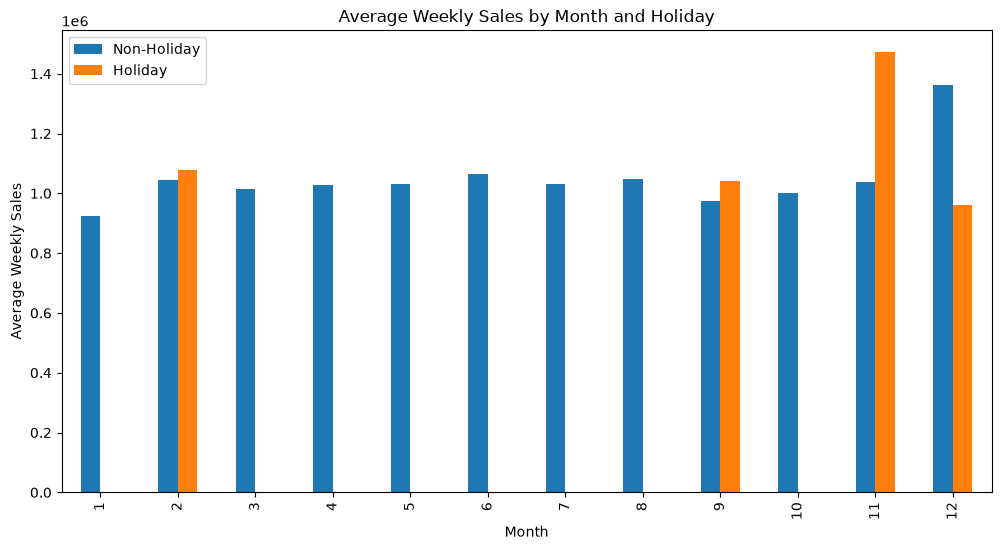

In [43]:
month_h_n_wsales.plot(kind='bar',figsize=(12,6))
plt.title("Average Weekly Sales by Month and Holiday")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.legend(["Non-Holiday", "Holiday"])
plt.show()

#### فروش در ماه 11 در هفته های تعطیل بالاست و ما باید دلیل این اختلاف را میان هفته تعطیل و هفته عادی را متوجه بشویم 

#### ما باید بدانیم این میزان فروش بر اساس چند رکورد گزارش شده است ممکن است بر اساس 2 رکورد میزان فروش مثلا شده باشد 1000000 یابراساس 90 تا رکورد شده باشد 1000000 درسته که هر دو فروش برابر هستند اما از نظر اطمینان این گونه نیست

In [44]:
pd.crosstab(df["Month"],df["Holiday_Flag"])

Holiday_Flag,0,1
Month,,
1,360,0
2,405,135
3,585,0
4,630,0
5,540,0
6,585,0
7,630,0
8,585,0
9,450,135


##### حال میدانیم میانگین فروش ماه 12 براساس 90 رکورد به دست آمده است بنابراین نتیجه گیری ما جدی تر است و میتوانیم بگوییم در داده های موجود در هفته های تعطیل ماه 12 با وجود 90 رکورد میانگین فروش پایین تر از هفته های غیر تعطیل بوده است. اما هنوز علت این تفاوت را نمیدانیم.

#### ما میدانیم تعطیلی با استفاده است 0و1 به ما نمایش داده میشود اما نوع تعطیلی را نمیدانیم مثلا نمیدانیم در ماه 11 و ماه 12 تفاوت تعطیلی به چه صورت است و ممکن است این تعطیلی ها با هم متفاوت باشند بنابراین میرویم سراغ خود تاریخ ها تا ببینیم این رکورد های تعطیل دقیقا مربوط به چه هفته هایی هستند.

In [45]:
df[df["Holiday_Flag"]==1][["Date","Month","Year","Weekly_Sales"]].sort_values("Date")

,Date,Month,Year,Weekly_Sales
1,2010-02-12,2,2010,1641957.44
3862,2010-02-12,2,2010,1558968.49
4005,2010-02-12,2,2010,529672.95
5864,2010-02-12,2,2010,575709.96
5149,2010-02-12,2,2010,529852.70
...,...,...,...,...
2280,2012-09-07,9,2012,537138.58
5855,2012-09-07,9,2012,1392143.82
3567,2012-09-07,9,2012,671482.90
1851,2012-09-07,9,2012,2165796.31


#### ما الان تاریخ همه رکوردهای تعطیل را داریم، ولی چون هر تاریخ برای ۴۵ فروشگاه تکرار شده، تاریخ‌های تکراری زیاد هستند.

In [46]:
df[df["Holiday_Flag"]==1]["Date"].unique()

<DatetimeArray>
['2010-02-12 00:00:00', '2010-09-10 00:00:00', '2010-11-26 00:00:00',
 '2010-12-31 00:00:00', '2011-02-11 00:00:00', '2011-09-09 00:00:00',
 '2011-11-25 00:00:00', '2011-12-30 00:00:00', '2012-02-10 00:00:00',
 '2012-09-07 00:00:00']
Length: 10, dtype: datetime64[us]

In [48]:
df[df["Holiday_Flag"]==1].groupby("Date")["Weekly_Sales"].sum().sort_values(ascending=False)

Date
2011-11-25    66593605.26
2010-11-26    65821003.24
2012-02-10    50009407.92
2010-02-12    48336677.63
2012-09-07    48330059.31
2011-02-11    47336192.79
2011-09-09    46763227.53
2011-12-30    46042461.04
2010-09-10    45634397.84
2010-12-31    40432519.00
Name: Weekly_Sales, dtype: float64